### Importación de datos



In [214]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


# 1. Análisis de facturación



In [215]:

tienda4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2358 entries, 0 to 2357
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2358 non-null   object 
 1   Categoría del Producto  2358 non-null   object 
 2   Precio                  2358 non-null   float64
 3   Costo de envío          2358 non-null   float64
 4   Fecha de Compra         2358 non-null   object 
 5   Vendedor                2358 non-null   object 
 6   Lugar de Compra         2358 non-null   object 
 7   Calificación            2358 non-null   int64  
 8   Método de pago          2358 non-null   object 
 9   Cantidad de cuotas      2358 non-null   int64  
 10  lat                     2358 non-null   float64
 11  lon                     2358 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.2+ KB


In [216]:
ingreso_tienda = tienda["Precio"].sum()
ingreso_tienda2 = tienda2["Precio"].sum()
ingreso_tienda3 = tienda3["Precio"].sum()
ingreso_tienda4 = tienda4["Precio"].sum()

print("Ingreso total de la tienda 1:", ingreso_tienda)
print("Ingreso total de la tienda 2:", ingreso_tienda2)
print("Ingreso total de la tienda 3:", ingreso_tienda3)
print("Ingreso total de la tienda 4:", ingreso_tienda4)

Ingreso total de la tienda 1: 1150880400.0
Ingreso total de la tienda 2: 1116343500.0
Ingreso total de la tienda 3: 1098019600.0
Ingreso total de la tienda 4: 1038375700.0


In [217]:
df_ingresos = pd.DataFrame({
    "Tienda": ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"],
    "Ingresos": [ingreso_tienda, ingreso_tienda2, ingreso_tienda3, ingreso_tienda4]
})

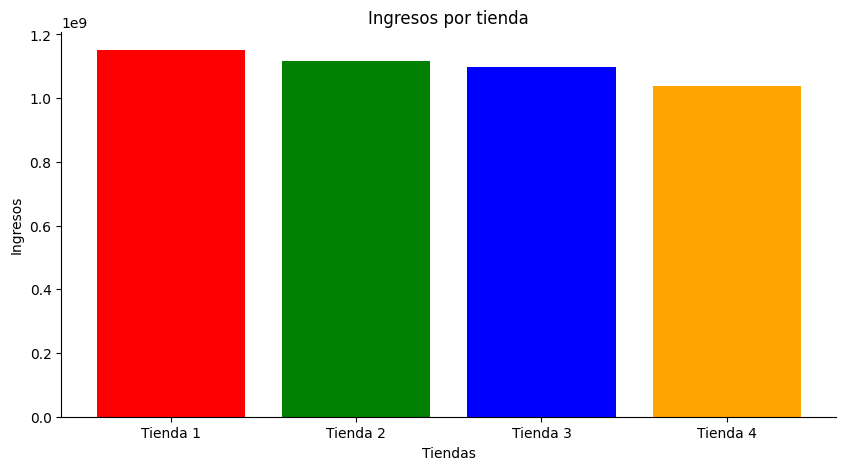

In [218]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(df_ingresos["Tienda"], df_ingresos["Ingresos"], color=['red', 'green', 'blue', 'orange'])

plt.title("Ingresos por tienda")
plt.xlabel("Tiendas")
plt.ylabel("Ingresos")
plt.xticks(rotation=0)
plt.gca().spines[['top','right']].set_visible(False)

plt.show()

# 2. Ventas por categoría

In [219]:
ventas_por_categoria = {
    "Tienda 1": tienda.groupby("Categoría del Producto")["Precio"].sum(),
    "Tienda 2": tienda2.groupby("Categoría del Producto")["Precio"].sum(),
    "Tienda 3": tienda3.groupby("Categoría del Producto")["Precio"].sum(),
    "Tienda 4": tienda4.groupby("Categoría del Producto")["Precio"].sum(),
}

ventas_por_categoria

{'Tienda 1': Categoría del Producto
 Artículos para el hogar     12698400.0
 Deportes y diversión        39290000.0
 Electrodomésticos          363685200.0
 Electrónicos               429493500.0
 Instrumentos musicales      91299000.0
 Juguetes                    17995700.0
 Libros                       8784900.0
 Muebles                    187633700.0
 Name: Precio, dtype: float64,
 'Tienda 2': Categoría del Producto
 Artículos para el hogar     14746900.0
 Deportes y diversión        34744500.0
 Electrodomésticos          348567800.0
 Electrónicos               410831100.0
 Instrumentos musicales     104990300.0
 Juguetes                    15945400.0
 Libros                      10091200.0
 Muebles                    176426300.0
 Name: Precio, dtype: float64,
 'Tienda 3': Categoría del Producto
 Artículos para el hogar     15060000.0
 Deportes y diversión        35593100.0
 Electrodomésticos          329237900.0
 Electrónicos               410775800.0
 Instrumentos musicales      7

# 3. Valoración promedio de la tienda


In [220]:
calificacion_tienda = tienda["Calificación"].mean()
calificacion_tienda2 = tienda2["Calificación"].mean()
calificacion_tienda3 = tienda3["Calificación"].mean()
calificacion_tienda4 = tienda4["Calificación"].mean()

print("Calificación promedio tienda 1:", calificacion_tienda)
print("Calificación promedio tienda 2:", calificacion_tienda2)
print("Calificación promedio tienda 3:", calificacion_tienda3)
print("Calificación promedio tienda 4:", calificacion_tienda4)

Calificación promedio tienda 1: 3.976685036032217
Calificación promedio tienda 2: 4.037303942348453
Calificación promedio tienda 3: 4.048325561678677
Calificación promedio tienda 4: 3.9957591178965224


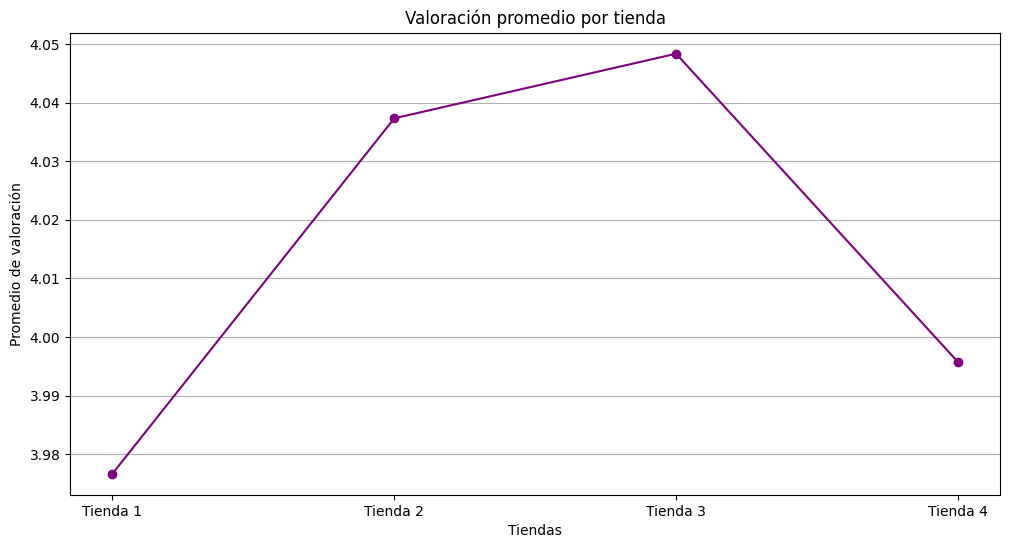

In [221]:

promedios = [
    tienda["Calificación"].mean(),
    tienda2["Calificación"].mean(),
    tienda3["Calificación"].mean(),
    tienda4["Calificación"].mean()
]

plt.figure(figsize=(12,6))
plt.plot(["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"], promedios, marker='o', color='purple')
plt.title("Valoración promedio por tienda")
plt.ylabel("Promedio de valoración")
plt.xlabel("Tiendas")
plt.grid(axis='y')
plt.show()

# 4. Productos más y menos vendidos

In [222]:
tiendas = [tienda, tienda2, tienda3, tienda4]

for i, t in enumerate(tiendas, start=1):
    producto = t["Producto"].value_counts().idxmax()
    cantidad = t["Producto"].value_counts().max()
    print(f"Producto más vendido en tienda {i}: {producto} (Cantidad: {cantidad})")

Producto más vendido en tienda 1: Microondas (Cantidad: 60)
Producto más vendido en tienda 2: Iniciando en programación (Cantidad: 65)
Producto más vendido en tienda 3: Kit de bancas (Cantidad: 57)
Producto más vendido en tienda 4: Cama box (Cantidad: 62)


# 5. Envío promedio por tienda

In [223]:
envio_tienda = tienda["Costo de envío"].mean()
envio_tienda2 = tienda2["Costo de envío"].mean()
envio_tienda3 = tienda3["Costo de envío"].mean()
envio_tienda4 = tienda4["Costo de envío"].mean()

print("Costo de envío promedio en Tienda 1:", envio_tienda)
print("Costo de envío promedio en Tienda 2:", envio_tienda2)
print("Costo de envío promedio en Tienda 3:", envio_tienda3)
print("Costo de envío promedio en Tienda 4:", envio_tienda4)

Costo de envío promedio en Tienda 1: 26018.60958033065
Costo de envío promedio en Tienda 2: 25216.235693090293
Costo de envío promedio en Tienda 3: 24805.680373039424
Costo de envío promedio en Tienda 4: 23459.457167090754


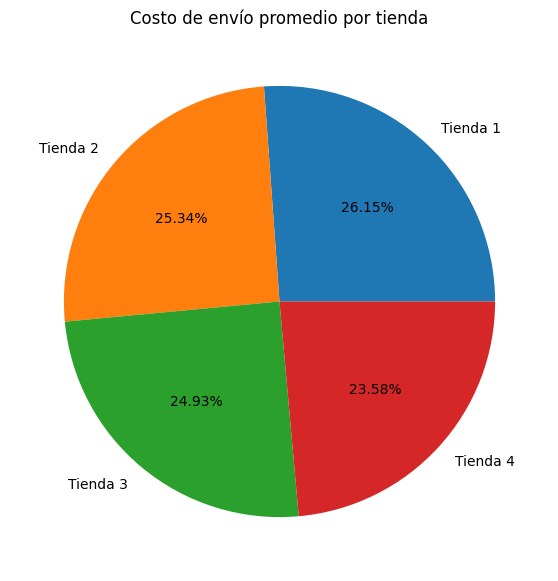

In [224]:
import matplotlib.pyplot as plt

envios = [envio_tienda, envio_tienda2, envio_tienda3, envio_tienda4]
labels = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]

plt.figure(figsize=(7,7))
plt.pie(envios, labels=labels, autopct='%1.2f%%')
plt.title("Costo de envío promedio por tienda")
plt.gca().set_aspect('equal')
plt.show()
     

# 6. Informe final

**Introducción**  
El propósito de este análisis es evaluar el desempeño de las cuatro tiendas del Sr.Juan para determinar cuál de ellas es la menos rentable o eficiente. El objetivo final es brindar al Sr. Juan una recomendación sobre qué tienda debería venderse, basándose en el análisis de sus ingresos totales, la aceptación de sus categorías de productos, la satisfacción del cliente y la eficiencia de sus costos logísticos.

**Análisis**  
1. De acuerdo con el análisis de facturación y la visualización de barras generada, existe una disparidad clara en la generación de capital entre las sedes:

* Tienda 1: Presenta el ingreso más alto con 1.150.880.400.
* Tienda 2: Registra ingresos por 1.116.343.500.
* Tienda 3: Alcanza una facturación de 1.098.019.600.
* Tienda 4: Se posiciona como la sucursal con el rendimiento financiero más bajo, recaudando 1.038.375.700.

2. El análisis de ventas por categoría permite identificar qué sucursales están perdiendo camino en los mercados clave:

* Los "Electrónicos" son el motor principal de todas las tiendas, pero la Tienda 4 muestra la cifra más baja en "Electrodomésticos" (283.260.200) comparada con los 363.685.200 de la Tienda 1.
* La categoría de "Libros" es la menos vendida en todas las sedes, representando una debilidad generalizada en el catálogo.
* Mientras que la Tienda 1 tiene éxito masivo con "Microondas" (60 unidades), la Tienda 4 depende de la venta de "Camas box" (62 unidades), un producto con logística más compleja.

3. A través del gráfico de líneas de valoración de promedio, se observan las siguientes tendencias:

* Tienda 3: Es la mejor calificada con un promedio de 4.048.
* Tienda 4: Aunque supera ligeramente a la Tienda 1, se mantiene en el rango bajo con 3.995.
* Tienda 1: Se encuentra en el último lugar de satisfacción con 3.976.

4. El costo de envío impacta directamente en la decisión de compra del cliente y en los márgenes de beneficio.

* Tienda 4: Es la más eficiente, con un costo promedio de $23,459.
* Tienda 1: Es la más costosa para realizar entregas, superando los $26,018 por envío.

**Conclusión**  
La elección de vender la Tienda 4 se fundamenta en que es la sucursal que genera los menores ingresos totales del grupo, con una diferencia de más de 112 millones con respecto a la Tienda 1. A pesar de ser la más eficiente en costos de envío, esta eficiencia no logra compensar su bajo volumen de ventas en categorías críticas como "Electrodomésticos", donde rinde significativamente menos que sus competidoras.

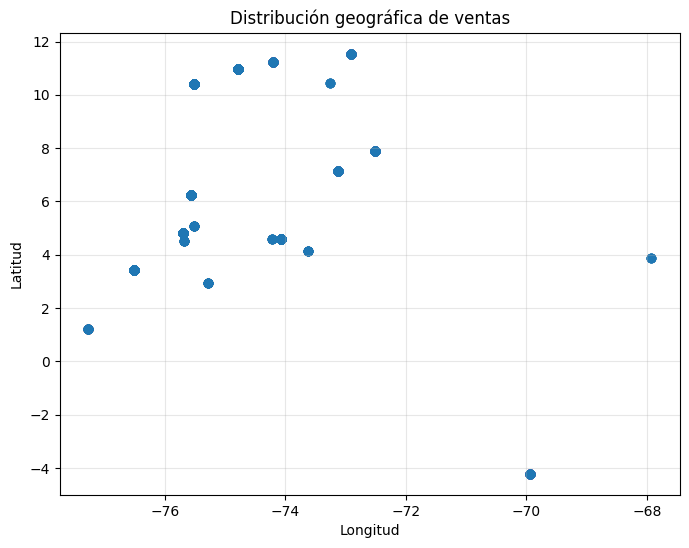

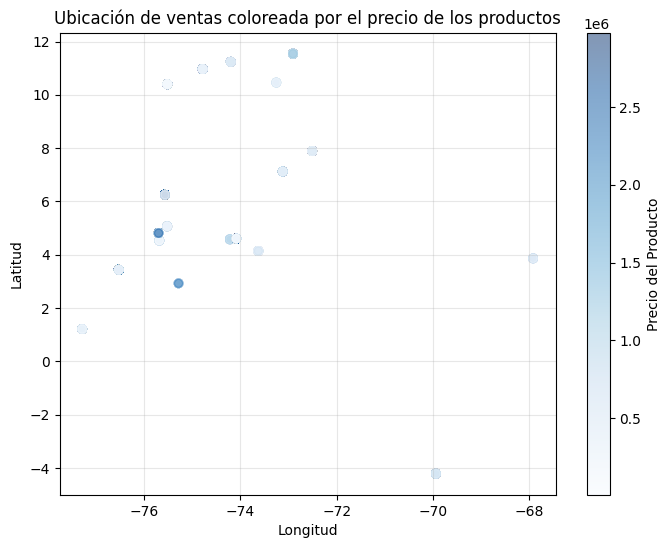

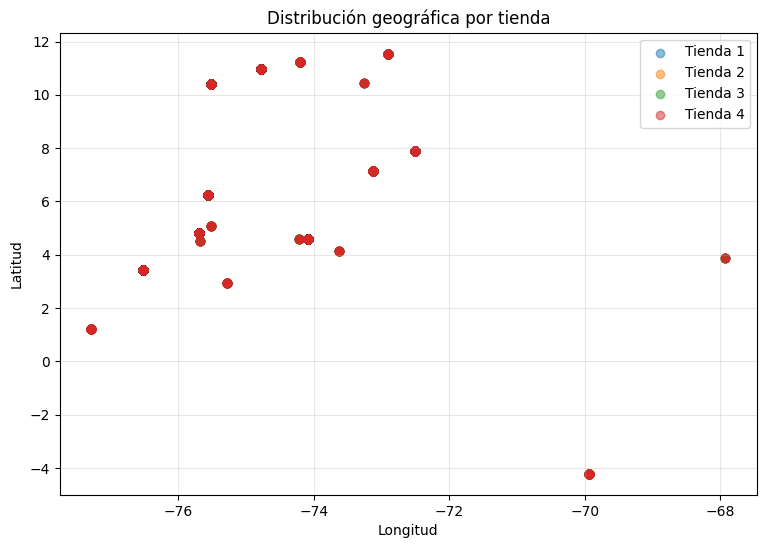

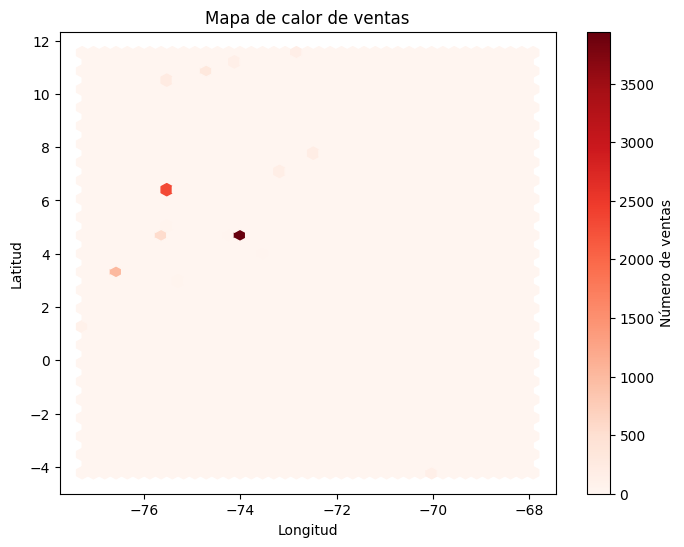

In [229]:
import pandas as pd
import matplotlib.pyplot as plt

# Todas las tiendas en un solo DF
dfs = [tienda, tienda2, tienda3, tienda4]
nombres = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]

# DF sin columna "Tienda"
df = pd.concat(dfs, ignore_index=True)

# DF con columna "Tienda"
df_con_tienda = pd.concat(
    [df_i.assign(Tienda=nombre) for df_i, nombre in zip(dfs, nombres)],
    ignore_index=True
)

# Scatter general
plt.figure(figsize=(8, 6))
plt.scatter(df['lon'], df['lat'], alpha=0.4)
plt.title('Distribución geográfica de ventas')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(alpha=0.3)
plt.show()
plt.close()

# Scatter precio
plt.figure(figsize=(8, 6))
plt.scatter(df['lon'], df['lat'], c=df['Precio'], alpha=0.5, cmap='Blues')
plt.title('Ubicación de ventas coloreada por el precio de los productos')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.colorbar(label='Precio del Producto')
plt.grid(alpha=0.3)
plt.show()
plt.close()

# Scatter tienda
plt.figure(figsize=(9, 6))

for tienda_nombre in df_con_tienda['Tienda'].unique():
    subset = df_con_tienda[df_con_tienda['Tienda'] == tienda_nombre]
    plt.scatter(subset['lon'], subset['lat'], alpha=0.5, label=tienda_nombre)

plt.title('Distribución geográfica por tienda')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
plt.close()

# Heatmap con hexbin
plt.figure(figsize=(8, 6))
plt.hexbin(df['lon'], df['lat'], gridsize=40, cmap='Reds')
plt.title('Mapa de calor de ventas')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.colorbar(label='Número de ventas')
plt.show()
plt.close()